<a href="https://colab.research.google.com/github/janosv246/MPA-MLF-Project/blob/main/MPA_MLF_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MPA-MLF Project**  

Vít Janoš, Kryštof Havrda

### 0. Import libraries

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns

from tensorflow import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from keras.optimizers import Adam
from keras.optimizers import AdamW
from keras.optimizers import SGD

#### 1.1 Set paths

In [2]:
drive.mount('/content/drive')
BASE_DIR = '/content/drive/MyDrive/data'

TRAIN_DIR = f'{BASE_DIR}/x_train'
TEST_DIR = f'{BASE_DIR}/x_test'
TRAIN_CSV = f'{BASE_DIR}/y_train_v2.csv'
SAMPLE_SUBMISSION_CSV = f'{BASE_DIR}/y_test_submission_example_v2.csv'

Mounted at /content/drive


#### 1.2 Load labels and image paths

In [3]:
def numeric_file_key(path_obj: Path):
    stem = path_obj.stem
    digits = ''.join(ch for ch in stem if ch.isdigit())
    return int(digits) if digits else stem


def find_id_and_label_columns(df: pd.DataFrame):
    lower_cols = [str(c).strip().lower() for c in df.columns]

    id_candidates = ['id', 'image', 'image_id', 'img_id', 'index']
    label_candidates = ['label', 'labels', 'class', 'target', 'y']

    id_col = None
    label_col = None

    for original, lower in zip(df.columns, lower_cols):
        if lower in id_candidates and id_col is None:
            id_col = original
        if lower in label_candidates and label_col is None:
            label_col = original

    if df.shape[1] == 1:
        label_col = df.columns[0]
        id_col = None
    elif df.shape[1] >= 2:
        if id_col is None:
            id_col = df.columns[0]
        if label_col is None:
            label_col = df.columns[1]

    return id_col, label_col


train_df = pd.read_csv(TRAIN_CSV)
train_id_col, train_label_col = find_id_and_label_columns(train_df)

train_image_paths = sorted(Path(TRAIN_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of training images: {len(train_image_paths)}')
print('Train CSV columns:', list(train_df.columns))

if train_id_col is None:
    train_labels_df = pd.DataFrame({
        'id': np.arange(1, len(train_df)),
        'label': train_df[train_label_col].to_numpy()
    })
else:
    train_labels_df = train_df[[train_id_col, train_label_col]].copy()
    train_labels_df.columns = ['id', 'label']

train_labels_df = train_labels_df.sort_values('id').reset_index(drop=True)
train_image_ids = np.array([numeric_file_key(p) for p in train_image_paths])

print(train_labels_df.head())

Number of training images: 9227
Train CSV columns: ['id', 'target']
   id  label
0   0      0
1   1      1
2   2      0
3   3      2
4   4      2


In [4]:
train_df



,id,target
0,0,0
1,1,1
2,2,0
3,3,2
4,4,2
...,...,...
9222,9222,2
9223,9223,3
9224,9224,1
9225,9225,3


#### 1.3 Show a few images

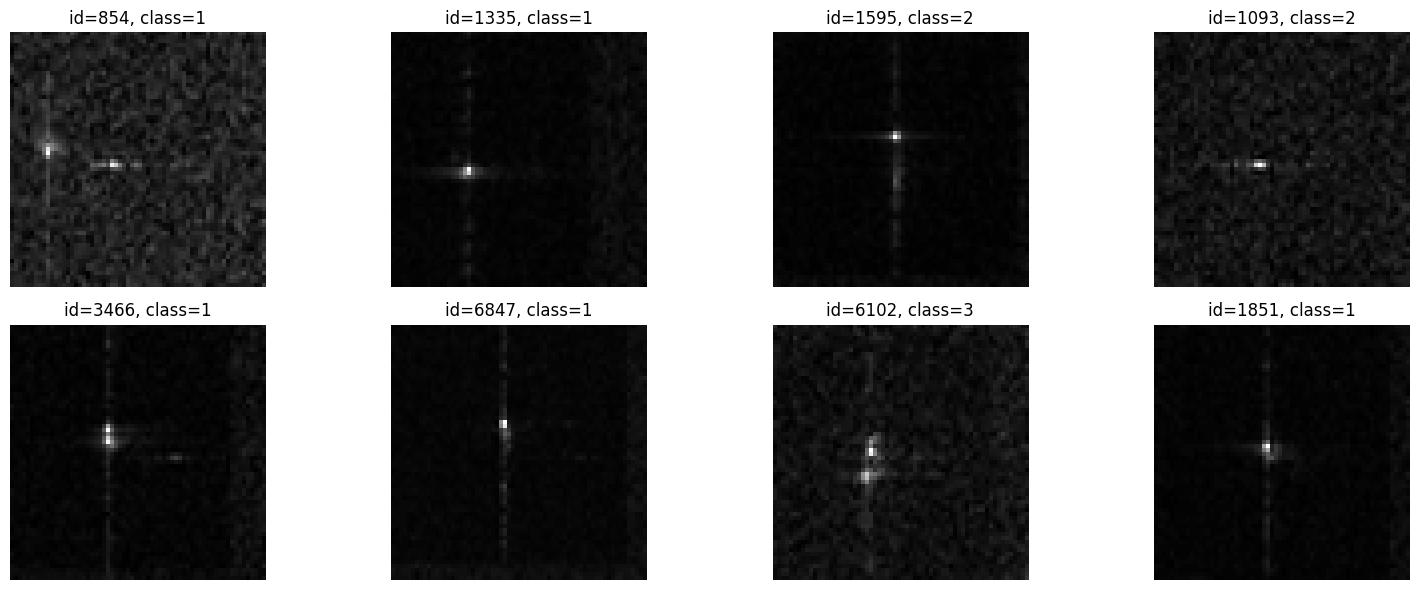

In [5]:
def load_grayscale_image(image_path, target_size=(51, 45)):
    image = Image.open(image_path).convert('L')
    image = image.resize(target_size)
    image = np.array(image, dtype=np.float32) / 255.0
    return image


def display_random_images(image_paths, labels_df, count=8, target_size=(64, 64)):
    selected_idx = np.random.choice(len(image_paths), size=count, replace=False)

    plt.figure(figsize=(16, 6))
    for i, idx in enumerate(selected_idx, 1):
        img_path = image_paths[idx]
        img_id = numeric_file_key(img_path)
        label_row = labels_df.loc[labels_df['id'] == img_id, 'label']
        label = int(label_row.iloc[0]) if len(label_row) > 0 else -1

        img = load_grayscale_image(img_path, target_size=target_size)

        plt.subplot(2, 4, i)
        plt.imshow(img, cmap='gray')
        plt.title(f'id={img_id}, class={label}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()


display_random_images(train_image_paths, train_labels_df)

#### 1.4 Load and preprocess the dataset

In [6]:
def build_dataset(image_paths, labels_df=None, target_size=(64, 64)):
    X = []
    y = []
    ids = []

    label_map = None
    if labels_df is not None:
        label_map = dict(zip(labels_df['id'].astype(int), labels_df['label'].astype(int)))

    for img_path in image_paths:
        img_id = int(numeric_file_key(img_path)-1)

        # Skip image if no label exists in label_map
        if label_map is not None and img_id not in label_map:
            continue

        img = load_grayscale_image(img_path, target_size=target_size)
        X.append(img)
        ids.append(img_id)

        if label_map is not None:
            y.append(label_map[img_id])

    X = np.array(X, dtype=np.float32)
    X = X.reshape(-1, target_size[0], target_size[1], 1)
    ids = np.array(ids)

    if label_map is not None:
        y = np.array(y, dtype=np.int32)
        return X, y, ids

    return X, ids


IMG_SIZE = (64, 64)
NUM_CLASSES = 4

X, y, train_ids = build_dataset(train_image_paths, train_labels_df, target_size=IMG_SIZE)
y_cat = to_categorical(y, NUM_CLASSES)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_cat, test_size=0.2, stratify=y
)

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_val shape: {y_val.shape}')
print('Classes:', np.unique(y))

X shape: (9227, 64, 64, 1)
y shape: (9227,)
X_train shape: (7381, 64, 64, 1)
X_val shape: (1846, 64, 64, 1)
y_train shape: (7381, 4)
y_val shape: (1846, 4)
Classes: [0 1 2 3]


### 2. Build the model

#### 2.1 Define the model structure

In [7]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(IMG_SIZE[0], IMG_SIZE[1], 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(NUM_CLASSES, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,625,092 (6.20 MB)

 Trainable params: 1,625,092 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Training stage

#### 3.1 Model training

In [8]:
epochs = 100
batch_size = 32

model.compile(optimizer=Adam(learning_rate=0.005), loss='categorical_crossentropy', metrics=['accuracy'])
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.5540 - loss: 0.9996 - val_accuracy: 0.7746 - val_loss: 0.5533
Epoch 2/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7783 - loss: 0.5279 - val_accuracy: 0.8137 - val_loss: 0.4220
Epoch 3/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8331 - loss: 0.4087 - val_accuracy: 0.8830 - val_loss: 0.2869
Epoch 4/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8600 - loss: 0.3516 - val_accuracy: 0.8933 - val_loss: 0.2796
Epoch 5/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8758 - loss: 0.3167 - val_accuracy: 0.9101 - val_loss: 0.2462
Epoch 6/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8819 - loss: 0.3017 - val_accuracy: 0.9155 - val_loss: 0.2161
Epoch 7/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8889 - loss: 0.2937 - val_accuracy: 0.9079 - val_loss: 0.2328
Epoch 8/100
231/231 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8936 - loss: 0.2749 - val_ac

#### 3.2 Plot training history

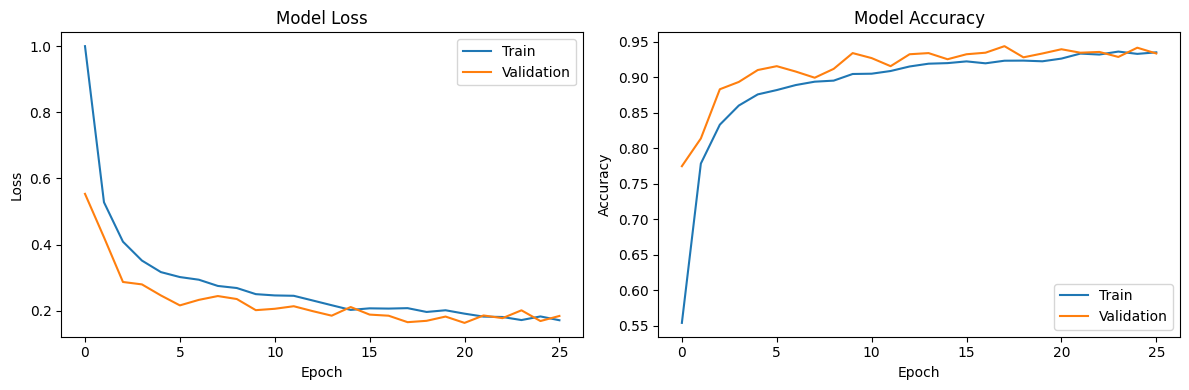

In [9]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

### 4. Model evaluation

Validation Loss: 0.1632
Validation Accuracy: 0.9393
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


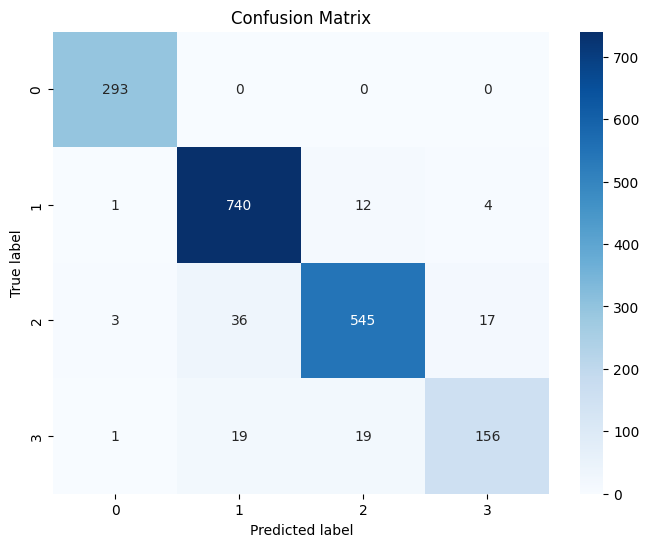

Macro F1 score: 0.9275
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       293
           1       0.93      0.98      0.95       757
           2       0.95      0.91      0.93       601
           3       0.88      0.80      0.84       195

    accuracy                           0.94      1846
   macro avg       0.94      0.92      0.93      1846
weighted avg       0.94      0.94      0.94      1846



In [10]:
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f'Validation Loss: {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy:.4f}')

val_pred_prob = model.predict(X_val)
val_pred = np.argmax(val_pred_prob, axis=1)
val_true = np.argmax(y_val, axis=1)

cm = confusion_matrix(val_true, val_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(NUM_CLASSES), yticklabels=range(NUM_CLASSES))
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix')
plt.show()

macro_f1 = f1_score(val_true, val_pred, average='macro')
print(f'Macro F1 score: {macro_f1:.4f}')
print(classification_report(val_true, val_pred))

In [11]:
def numeric_file_key(path_obj: Path):
    stem = path_obj.stem
    digits = ''.join(ch for ch in stem if ch.isdigit())
    return int(digits) if digits else stem


def find_id_and_label_columns(df: pd.DataFrame):
    lower_cols = [str(c).strip().lower() for c in df.columns]

    id_candidates = ['id', 'image', 'image_id', 'img_id', 'index']
    label_candidates = ['label', 'labels', 'class', 'target', 'y']

    id_col = None
    label_col = None

    for original, lower in zip(df.columns, lower_cols):
        if lower in id_candidates and id_col is None:
            id_col = original
        if lower in label_candidates and label_col is None:
            label_col = original

    if df.shape[1] == 1:
        label_col = df.columns[0]
        id_col = None
    elif df.shape[1] >= 2:
        if id_col is None:
            id_col = df.columns[0]
        if label_col is None:
            label_col = df.columns[1]

    return id_col, label_col


train_df = pd.read_csv(SAMPLE_SUBMISSION_CSV)
train_id_col, train_label_col = find_id_and_label_columns(train_df)

train_image_paths = sorted(Path(TEST_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of training images: {len(train_image_paths)}')
print('Train CSV columns:', list(train_df.columns))

if train_id_col is None:
    train_labels_df = pd.DataFrame({
        'id': np.arange(1, len(train_df)),
        'label': train_df[train_label_col].to_numpy()
    })
else:
    train_labels_df = train_df[[train_id_col, train_label_col]].copy()
    train_labels_df.columns = ['id', 'label']

train_labels_df = train_labels_df.sort_values('id').reset_index(drop=True)
train_image_ids = np.array([numeric_file_key(p) for p in train_image_paths])

print(train_labels_df.head())

Number of training images: 3955
Train CSV columns: ['id', 'target']
     id  label
0  9227      0
1  9228      3
2  9229      2
3  9230      3
4  9231      3


In [ ]:
test_image_paths = sorted(Path(TEST_DIR).glob('*.png'), key=numeric_file_key)
print(f'Number of test images: {len(test_image_paths)}')

X_test, test_ids = build_dataset(test_image_paths, labels_df=None, target_size=IMG_SIZE)

print(f'X_test shape: {X_test.shape}')

# Make predictions
test_pred_prob = model.predict(X_test)
test_pred = np.argmax(test_pred_prob, axis=1)

# Create submission DataFrame
submission_df = pd.DataFrame({
    'id': test_ids,
    'target': test_pred
})

# Sort by id to match expected submission format
submission_df = submission_df.sort_values('id').reset_index(drop=True)

print(submission_df.head())

# Save submission file
submission_path = f'{BASE_DIR}/submission.csv'
submission_df.to_csv(submission_path, index=False)
print(f'Submission file saved to {submission_path}')

Number of test images: 3955
